In [31]:
import pandas as pd 
import matplotlib.pyplot as plt

In [32]:
df=pd.read_csv(r'D:\Saran\penguins.csv')

In [33]:
df

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,NaN,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...
339,NaN,NaN,NaN,NaN,NaN
340,46.8,14.3,215.0,4850.0,FEMALE
341,50.4,15.7,222.0,5750.0,MALE
342,45.2,14.8,212.0,5200.0,FEMALE


In [34]:
df.isnull().sum()

culmen_length_mm     2
culmen_depth_mm      2
flipper_length_mm    2
body_mass_g          2
sex                  9
dtype: int64

In [35]:
df[['culmen_length_mm','culmen_depth_mm','flipper_length_mm','body_mass_g']]=df[['culmen_length_mm','culmen_depth_mm','flipper_length_mm','body_mass_g']].fillna(0)

In [36]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

In [37]:
le=LabelEncoder()

df['sex']=le.fit_transform(df['sex'])

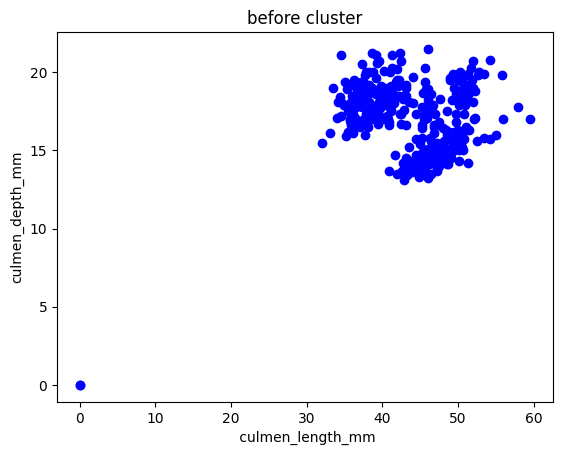

In [38]:
plt.scatter(df['culmen_length_mm'], df['culmen_depth_mm'], color='blue')
plt.xlabel(' culmen_length_mm')
plt.ylabel( 'culmen_depth_mm')
plt.title('before cluster')
plt.show()


In [45]:
kmeans=KMeans(n_clusters=3,random_state=42)
df['Cluster']=kmeans.fit_predict(df)

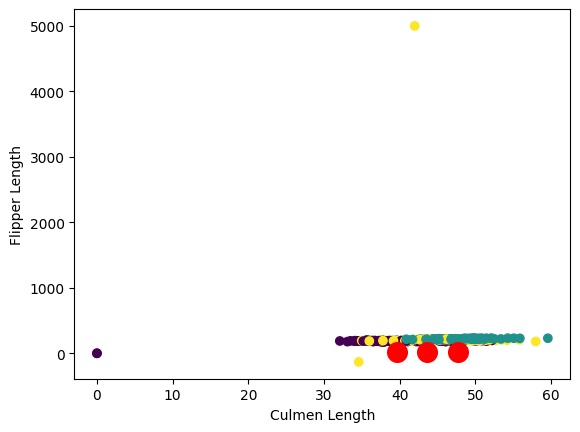

In [66]:
import matplotlib.pyplot as plt

plt.scatter(df['culmen_length_mm'], df['flipper_length_mm'], c=df['Cluster'])
plt.xlabel("Culmen Length")
plt.ylabel("Flipper Length")

plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            s=200, c='red', label='Centroids')

plt.show()


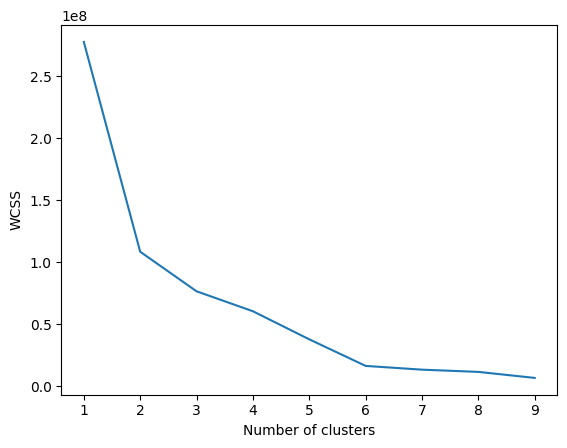

In [47]:
wcss = []

for i in range(1,10):
    km = KMeans(n_clusters=i)
    km.fit(df)
    wcss.append(km.inertia_)

plt.plot(range(1,10), wcss)
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

In [68]:
from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import dendrogram,linkage

In [71]:
hc=AgglomerativeClustering(n_clusters=3,linkage='ward')
df['Cluster']=hc.fit_predict(df)

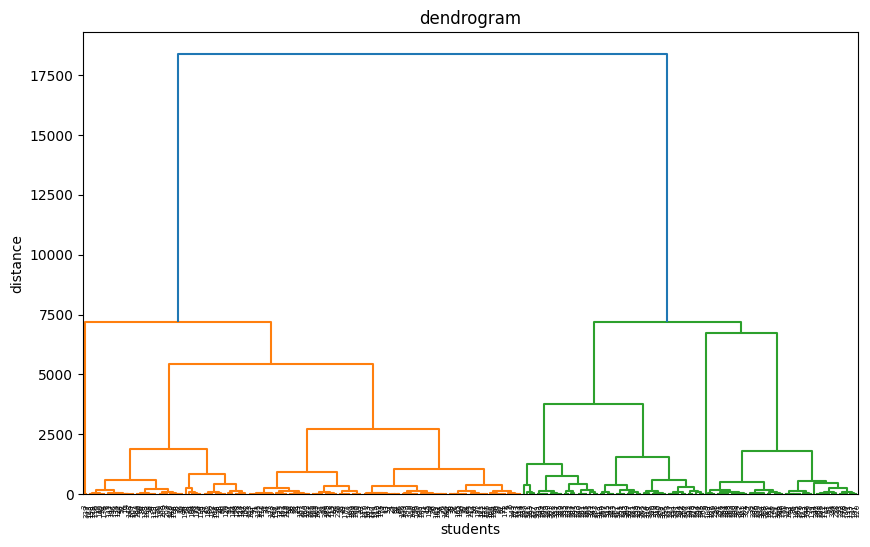

In [72]:
linked=linkage(df,method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked)
plt.xlabel('students')
plt.ylabel('distance')
plt.title('dendrogram')
plt.show()

In [73]:
hc=AgglomerativeClustering(n_clusters=3,linkage='ward')
df['Cluster']=hc.fit_predict(df)

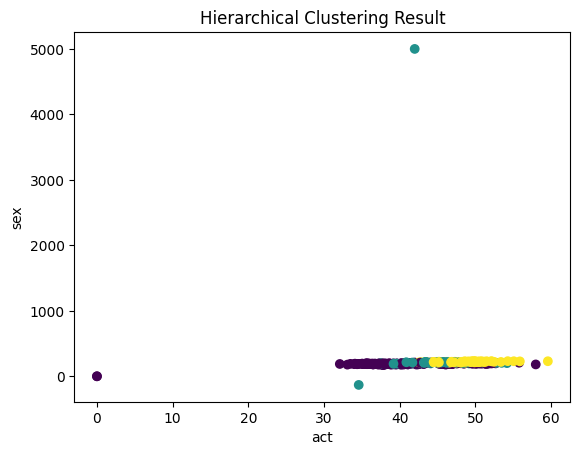

In [76]:
plt.scatter(df['culmen_length_mm'], df['flipper_length_mm'],
            c=df['Cluster'], cmap='viridis')

plt.xlabel('act')
plt.ylabel('sex')
plt.title('Hierarchical Clustering Result')
plt.show()


In [77]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def divisive_visual(df, depth=2, level=0, pos=0):

    if depth == 0 or len(df) <= 2:
        plt.text(level, pos, f"{len(df)} points")
        return

    kmeans = KMeans(n_clusters=2, random_state=42)
    labels = kmeans.fit_predict(df)

    left = df[labels == 0]
    right = df[labels == 1]

    plt.text(level, pos, f"{len(df)}")

    offset = 2 ** (depth - level)

    plt.plot([level, level+1], [pos, pos+offset], 'k-')
    plt.plot([level, level+1], [pos, pos-offset], 'k-')

    divisive_visual(left, depth-1, level+1, pos+offset)
    divisive_visual(right, depth-1, level+1, pos-offset)

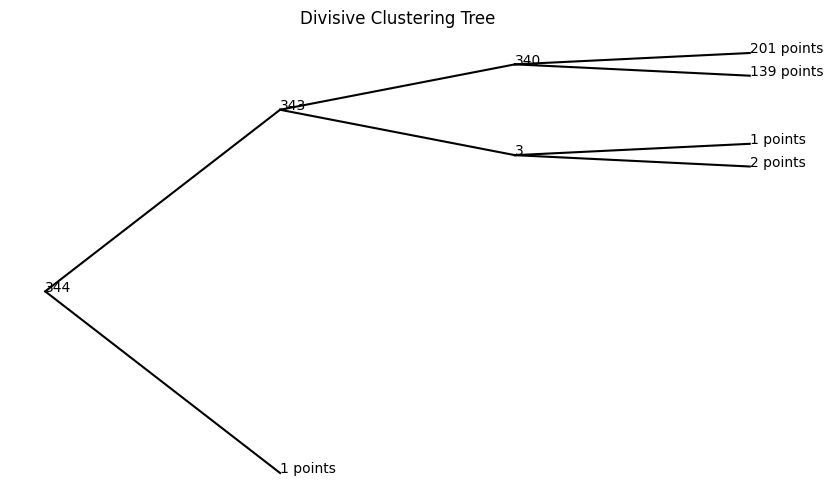

In [78]:
X = df[['culmen_length_mm','flipper_length_mm']].values

plt.figure(figsize=(10,6))
divisive_visual(X, depth=3)
plt.title("Divisive Clustering Tree")
plt.axis("off")
plt.show()

In [80]:
from sklearn.preprocessing import StandardScaler


In [81]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
scaled_data

array([[-7.15821262e-01,  6.98756086e-01, -1.22226944e-01,
        -4.96900475e-01,  8.29650699e-01, -8.03449633e-01],
       [-6.53120259e-01,  1.47735593e-01, -1.02990935e-01,
        -4.38759739e-01, -9.76677405e-01, -8.03449633e-01],
       [-5.27718253e-01,  4.02052743e-01, -6.83661183e-02,
        -1.07830783e+00, -9.76677405e-01, -8.03449633e-01],
       ...,
       [ 1.05548207e+00, -5.72829667e-01,  3.55083307e-02,
         1.82872896e+00,  8.29650699e-01,  1.59991275e+00],
       [ 2.40369034e-01, -9.54305393e-01, -2.96368744e-03,
         1.18918086e+00, -9.76677405e-01,  1.59991275e+00],
       [ 9.77105820e-01, -4.03284900e-01,  8.83514370e-04,
         1.42174381e+00,  8.29650699e-01,  1.59991275e+00]],
      shape=(344, 6))

In [83]:
from sklearn.decomposition import PCA

In [91]:
pca=PCA(n_components=3)

principal_components=pca.fit_transform(scaled_data)

pca_df=pd.DataFrame(principal_components,columns=['PC1','PC2','PC3'])

pca_df

,PC1,PC2,PC3
0,-1.070249,0.824147,-0.359151
1,-1.265364,-0.385990,0.163344
2,-1.638787,-0.167227,0.170510
3,-4.822417,-6.583271,0.431752
4,-1.856541,0.093228,0.139444
...,...,...,...
339,-4.822417,-6.583271,0.431752
340,1.652361,-1.511921,0.403659
341,2.803088,-0.032456,-0.186014
342,1.745263,-1.412972,0.376004


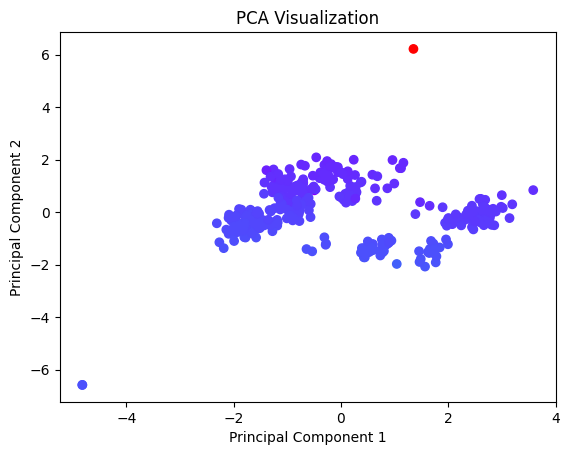

In [101]:
plt.scatter(pca_df['PC1'], pca_df['PC2'] , c=pca_df['PC3'] ,  cmap='rainbow')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization')
plt.show()

In [87]:
from sklearn.cluster import DBSCAN

In [88]:
dbscan = DBSCAN(eps=3, min_samples=2)
df['Cluster'] = dbscan.fit_predict(df)

print("\nClustered Data:\n", df)


Clustered Data:
      culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g  sex  \
0                39.1             18.7              181.0       3750.0    2   
1                39.5             17.4              186.0       3800.0    1   
2                40.3             18.0              195.0       3250.0    1   
3                 0.0              0.0                0.0          0.0    3   
4                36.7             19.3              193.0       3450.0    1   
..                ...              ...                ...          ...  ...   
339               0.0              0.0                0.0          0.0    3   
340              46.8             14.3              215.0       4850.0    1   
341              50.4             15.7              222.0       5750.0    2   
342              45.2             14.8              212.0       5200.0    1   
343              49.9             16.1              213.0       5400.0    2   

     Cluster  
0         -1  
1  

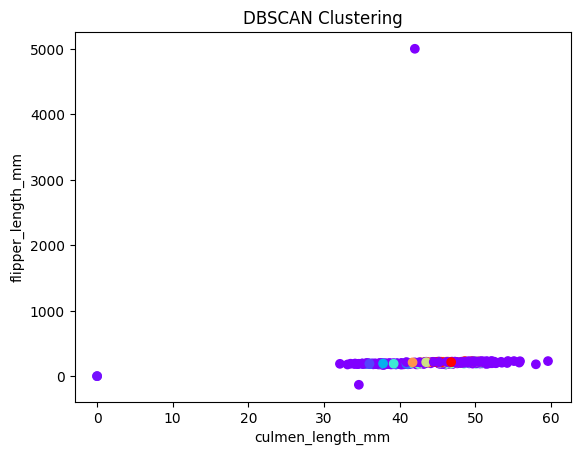

In [89]:
plt.scatter(df['culmen_length_mm'], df['flipper_length_mm'], c=df['Cluster'], cmap='rainbow')
plt.xlabel('culmen_length_mm')
plt.ylabel('flipper_length_mm')
plt.title('DBSCAN Clustering')
plt.show()